In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import seaborn as sns
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import OptimalBattery.construct as ct
import OptimalBattery.plot as plot
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import pandas as pd


Default device set to: cuda


# define atlas and dirs

In [2]:
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')
connectivity_dir = os.path.join(base_dir, 'OptimalBattery', 'connectivity')
#check if the directories exist
if not os.path.exists(connectivity_dir):
    os.makedirs(connectivity_dir)
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')


In [3]:
subj = None

In [4]:
space = 'SUIT3'
suit_atlas,_= am.get_atlas(atlas_str=space)

data_mdtb_s1_run_suit,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun',subj=subj)
data_mdtb_s1_run_suit[np.isnan(data_mdtb_s1_run_suit)] = 0



data_mdtb_s1_all_suit,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll',subj=subj)
data_mdtb_s1_all_suit[np.isnan(data_mdtb_s1_all_suit)] = 0


data_mdtb_s2_all_suit,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll',subj=subj)
data_mdtb_s2_all_suit[np.isnan(data_mdtb_s2_all_suit)] = 0

In [5]:
space ='fs32k'
fs_atlas,_= am.get_atlas(atlas_str=space)
data_mdtb_s1_run_fs,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun',subj=subj)
data_mdtb_s1_run_fs[np.isnan(data_mdtb_s1_run_fs)] = 0

data_mdtb_s1_all_fs,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll',subj=subj)
data_mdtb_s1_all_fs[np.isnan(data_mdtb_s1_all_fs)] = 0

data_mdtb_s2_all_fs,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll',subj=subj)
data_mdtb_s2_all_fs[np.isnan(data_mdtb_s2_all_fs)] = 0

In [6]:
data_mdtb_s1_run_fs = ut.recenter_fmri_data(data_mdtb_s1_run_fs,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
data_mdtb_s1_all_fs = ut.recenter_fmri_data(data_mdtb_s1_all_fs,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_run_fs.shape)
print(data_mdtb_s1_all_fs.shape)

(24, 464, 59518)
(24, 29, 59518)


# Get crossvalidated second moment matrix (GLib)

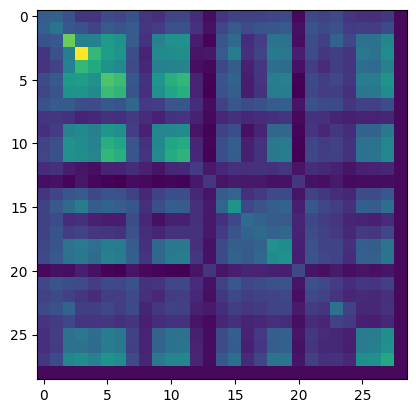

In [7]:
G_lib =  ct.get_G(data=data_mdtb_s1_run_fs,n_cond=29,n_part=16)
plt.imshow(G_lib)

In [8]:
condition_df= ct.get_condition_indices(info_mdtb_1_run)

In [9]:
D = ev.real_connectivity(G_lib, condition_df,
                      data_mdtb_s1_run_fs,data_mdtb_s1_run_suit, # training data
                      data_mdtb_s2_all_fs,data_mdtb_s2_all_suit, # test data
                      battery_sizes = [3,4,5,6,7,8,10,12,14,16],
                      metrics  = ['random','variance','variance_mc','log_det_mc','inverse_trace_mc'],
                      n_batteries = 10000,
                      rest_idx = None,
                      n_iter=10)


Evaluating battery size: 3
Iteration: 0
Evaluating metric: random
Evaluating metric: variance
Evaluating metric: variance_mc
Evaluating metric: log_det_mc
Evaluating metric: inverse_trace_mc
Iteration: 1
Evaluating metric: random
Evaluating metric: variance
Evaluating metric: variance_mc
Evaluating metric: log_det_mc
Evaluating metric: inverse_trace_mc
Iteration: 2
Evaluating metric: random
Evaluating metric: variance
Evaluating metric: variance_mc
Evaluating metric: log_det_mc
Evaluating metric: inverse_trace_mc
Iteration: 3
Evaluating metric: random
Evaluating metric: variance
Evaluating metric: variance_mc
Evaluating metric: log_det_mc
Evaluating metric: inverse_trace_mc
Iteration: 4
Evaluating metric: random
Evaluating metric: variance
Evaluating metric: variance_mc
Evaluating metric: log_det_mc
Evaluating metric: inverse_trace_mc
Iteration: 5
Evaluating metric: random
Evaluating metric: variance
Evaluating metric: variance_mc
Evaluating metric: log_det_mc
Evaluating metric: invers

In [4]:
D = pd.read_csv('temp.tsv', sep='\t')

In [5]:
D_averaged_across_iter = averaged_df = plot.average_per_subject(D,'correlation') # lists of subjects are averaged across iterations
long_df = averaged_df.explode('avg_correlation_per_subject') # expands the list of subjects into rows for each subject
long_df['avg_correlation_per_subject'] = long_df['avg_correlation_per_subject'].astype(float) # turns each correaltion for each subject into a float 

In [ ]:
# long_df.to_csv('eval_tsvs/real_connectivity.tsv',index=False,sep='\t')
long_df = pd.read_csv('eval_tsvs/eval_tsvs/real_connectivity.tsv',sep='\t')

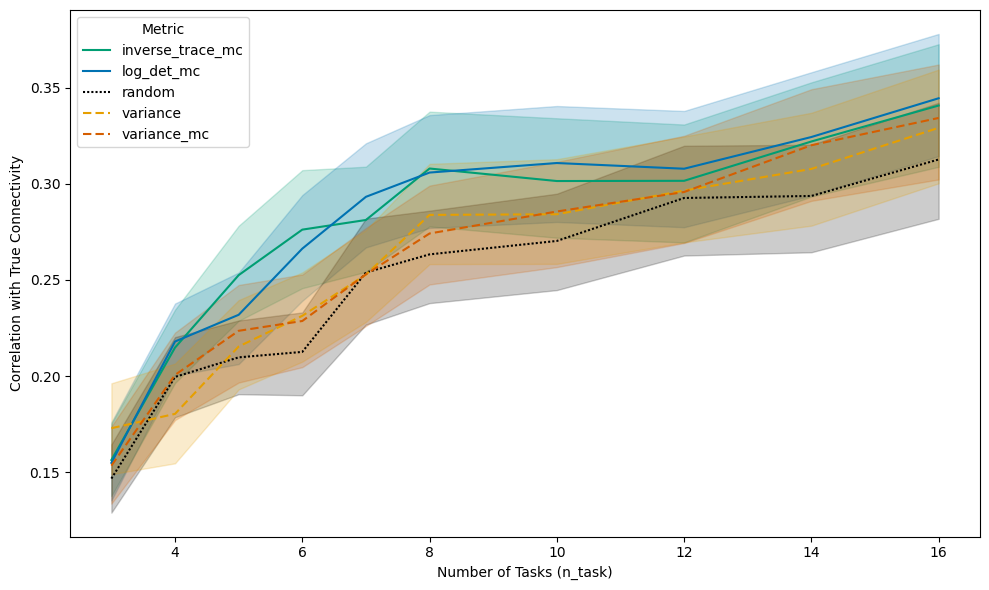

In [7]:
custom_palette = {
    'random': 'black',
    'variance': '#E69F00',
    'variance_mc': '#D55E00',
    'log_det_mc': '#0072B2',
    'inverse_trace_mc': '#009E73'
}

custom_dashes = {
    'random': (1, 1),            # dotted
    'variance': (4, 2),              # dashed
    'variance_mc': (4, 2),           # dashed
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=long_df,
    x="n_task",
    y="avg_correlation_per_subject",
    hue="metric",
    style="metric",
    palette=custom_palette,
    dashes=custom_dashes
)

plt.xlabel("Number of Tasks (n_task)")
plt.ylabel("Correlation with True Connectivity")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()